In [ ]:
import numpy as np
from PIL import Image
import cc3d
import glob

# 读取预测掩码
gt_dir = '/home/xkw/pxlames/segmentation/data/FIVE/all/1st_manual'
gt_paths = glob.glob(gt_dir + '/*.png')
all_sizes = []

for gt_path in gt_paths:
    pred = np.array(Image.open(gt_path))
    labels = cc3d.connected_components(pred)
    
    # 统计每个图像中连通分量的大小
    for label in range(1, labels.max() + 1):
        size = (labels == label).sum()
        all_sizes.append(size)

# 打印最小的10个连通分量大小
sorted_sizes = sorted(all_sizes)
print("最小的10个连通分量大小:")
for i in range(100):
    print(f"第{i+1}小: {sorted_sizes[i]}")

In [ ]:
import matplotlib.pyplot as plt

# 去掉大小为1的连通分量
filtered_sizes = [size for size in all_sizes if size > 1]

# 打印前100小的分量大小
sorted_sizes = sorted(filtered_sizes)
print("去掉大小为1后,最小的100个连通分量大小:")
for i in range(100):
    print(f"第{i+1}小: {sorted_sizes[i]}")

# 绘制直方图
plt.figure(figsize=(10, 6))
plt.hist(filtered_sizes, bins=50, edgecolor='black')
plt.title('血管连通分量大小分布(不含大小为1)')
plt.xlabel('连通分量大小(像素)')
plt.ylabel('频数')
plt.legend()

# 绘制箱线图
plt.figure(figsize=(10, 6))
plt.boxplot(filtered_sizes)
plt.title('血管连通分量大小箱线图(不含大小为1)')
plt.ylabel('连通分量大小(像素)')

# 打印统计信息
print(f"平均大小: {np.mean(filtered_sizes):.2f}")
print(f"中位数: {np.median(filtered_sizes):.2f}")
print(f"标准差: {np.std(filtered_sizes):.2f}")
print(f"最小值: {np.min(filtered_sizes)}")
print(f"最大值: {np.max(filtered_sizes)}")


In [6]:
import numpy as np
from PIL import Image
import cc3d
import glob
import matplotlib.pyplot as plt
import os

# 读取所有gt图片
gt_dir = '/home/xkw/pxlames/segmentation/data/FIVE/all/1st_manual'
gt_paths = glob.glob(os.path.join(gt_dir, '*.png'))

# 用于存储所有图片的统计信息
min_values = []

# 遍历每张图片
for gt_path in gt_paths:
    img = np.array(Image.open(gt_path).convert('L'))
    img = img/255.0 # 归一化到0-1

    # 使用connected components分析连通分量
    labels = cc3d.connected_components(img)

    # 统计每个连通分量的大小
    sizes = []
    for label in range(1, labels.max() + 1):
        size = (labels == label).sum()
        sizes.append(size)

    # 检查 sizes 是否为空
    if sizes:
        # 计算统计信息
        stats = {
            '图片名': os.path.basename(gt_path),
            '连通分量数量': len(sizes),
            '平均大小': np.mean(sizes),
            '中位数': np.median(sizes),
            '标准差': np.std(sizes),
            '最小值': np.min(sizes),
            '最大值': np.max(sizes)
        }
        min_values.append(np.min(sizes))
    else:
        # 如果 sizes 为空，设置默认值或跳过
        print(f"图片 {os.path.basename(gt_path)} 没有连通分量，跳过统计。")
        continue
    
    # 打印每张图片的统计信息
    # print(f"\n图片 {stats['图片名']} 的统计信息:")
    # print(f"连通分量数量: {stats['连通分量数量']}")
    # print(f"平均大小: {stats['平均大小']:.2f}")
    # print(f"中位数: {stats['中位数']:.2f}")
    # print(f"标准差: {stats['标准差']:.2f}")
    # print(f"最小值: {stats['最小值']}")
    # print(f"最大值: {stats['最大值']}")
    
    if(stats['最小值'] >= 1 and stats['最小值'] <= 10):
        print(f"\n图片 {stats['图片名']} 的统计信息:")


# 计算所有图片的平均统计信息
min(min_values)



图片 261_D.png 的统计信息:
图片 447_G.png 没有连通分量，跳过统计。

图片 108_A.png 的统计信息:
图片 448_G.png 没有连通分量，跳过统计。


2

/tmp/ipykernel_2766278/2376180656.py:34: UserWarning: Glyph 22788 (\N{CJK UNIFIED IDEOGRAPH-5904}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2766278/2376180656.py:34: UserWarning: Glyph 29702 (\N{CJK UNIFIED IDEOGRAPH-7406}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2766278/2376180656.py:34: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2766278/2376180656.py:34: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from current font.
  plt.tight_layout()


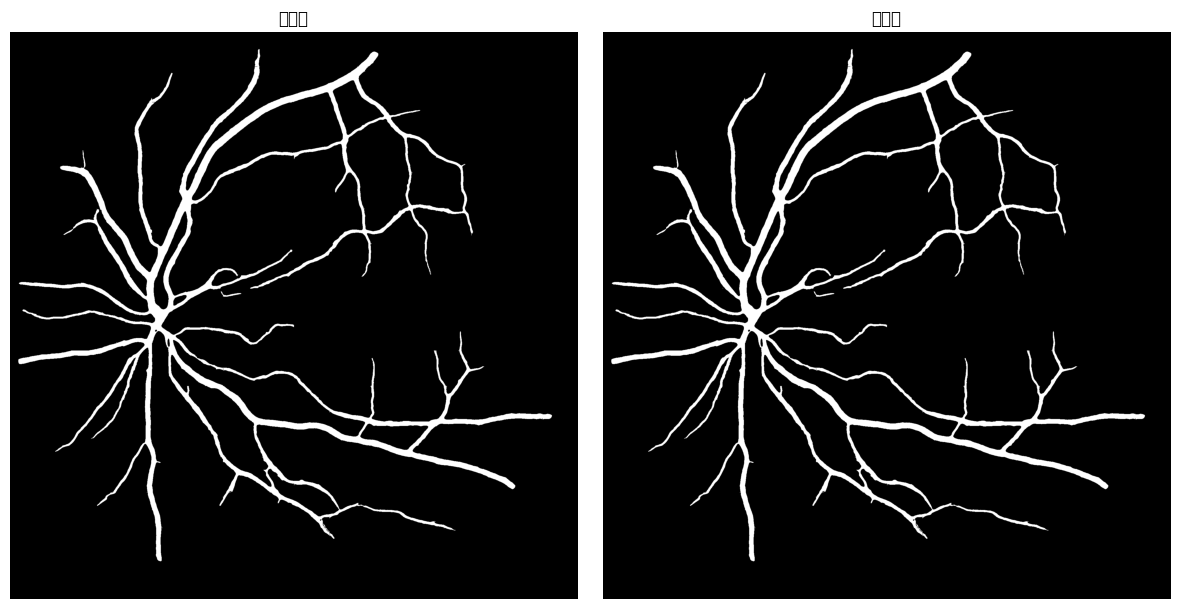

True

In [5]:
import cv2
import cc3d
import numpy as np
import matplotlib.pyplot as plt

gt_dir = '/home/xkw/pxlames/segmentation/data/FIVE/all/1st_manual/261_D.png'

# 读取图像
img = cv2.imread(gt_dir, cv2.IMREAD_GRAYSCALE)
img = img / 255.0  # 归一化到0-1

# 使用connected components分析连通分量
labels = cc3d.connected_components(img)

# 找到大小为1的连通分量
for label in range(1, labels.max() + 1):
    if (labels == label).sum() == 1:
        # 将大小为1的连通分量设为背景(0)
        img[labels == label] = 0

# 绘制处理前后的对比图
plt.figure(figsize=(12, 6))

plt.subplot(121)
plt.imshow(cv2.imread(gt_dir, cv2.IMREAD_GRAYSCALE), cmap='gray')
plt.title('处理前')
plt.axis('off')

plt.subplot(122)
plt.imshow(img, cmap='gray')
plt.title('处理后')
plt.axis('off')

plt.tight_layout()
plt.show()

# 保存修改后的图像
cv2.imwrite(gt_dir, (img * 255).astype(np.uint8))
# 108_A.png

